In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,f1_score,recall_score,confusion_matrix


In [43]:
main_df = pd.read_csv("/Users/utkuseyithanoglu/Desktop/nyc car crash analysis/data/raw/clean_crash_data.csv")

In [44]:
main_df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,0,1,0,Unspecified,4675373,2,0,1,1,Other
1,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,0,0,0,Unspecified,4456314,5,1,9,0,Car
2,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,0,0,0,Unspecified,4486609,1,0,8,0,Other
3,2021-12-14,17:05,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,...,0,0,0,Passing Too Closely,4486555,1,0,17,0,Car
4,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,0,2,0,Unspecified,4486660,1,0,8,1,Car


In [45]:
main_df.isna().sum()

CRASH DATE                       0
CRASH TIME                       0
BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
NUMBER OF PERSONS INJURED        0
NUMBER OF PERSONS KILLED         0
NUMBER OF PEDESTRIANS INJURED    0
NUMBER OF PEDESTRIANS KILLED     0
NUMBER OF CYCLIST INJURED        0
NUMBER OF CYCLIST KILLED         0
NUMBER OF MOTORIST INJURED       0
NUMBER OF MOTORIST KILLED        0
CONTRIBUTING FACTOR VEHICLE 1    0
COLLISION_ID                     0
day_of_week                      0
is_weekend                       0
hour                             0
injury_flag                      0
vehicle_category                 0
dtype: int64

In [46]:
main_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,0,1,0,Unspecified,4675373,2,0,1,1,Other
1,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,0,0,0,Unspecified,4456314,5,1,9,0,Car
2,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,0,0,0,Unspecified,4486609,1,0,8,0,Other
3,2021-12-14,17:05,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,...,0,0,0,Passing Too Closely,4486555,1,0,17,0,Car
4,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,0,2,0,Unspecified,4486660,1,0,8,1,Car
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2036392,2026-03-03,12:40,BRONX,10453,40.854816,-73.911500,3.0,0.0,0,0,...,0,3,0,Driver Inattention/Distraction,4882931,1,0,12,1,Other
2036393,2026-03-03,19:19,UNKNOWN,0,40.665520,-73.744670,0.0,0.0,0,0,...,0,0,0,Following Too Closely,4882837,1,0,19,0,SUV
2036394,2026-02-28,23:50,MANHATTAN,10002,40.721798,-73.988240,0.0,0.0,0,0,...,0,0,0,Unspecified,4883299,5,1,23,0,SUV
2036395,2026-03-03,22:15,UNKNOWN,0,40.834114,-73.863270,2.0,0.0,0,0,...,0,2,0,Other Vehicular,4883343,1,0,22,1,SUV


In [69]:
main_df["CRASH TIME"] = pd.to_datetime(main_df["CRASH TIME"], format="%H:%M")

In [70]:
main_df['hour'] = main_df['CRASH TIME'].dt.hour

In [71]:
main_df = main_df.drop(columns=['CRASH TIME'])

In [47]:
main_df.groupby('BOROUGH')['injury_flag'].mean()

BOROUGH
BRONX            0.256010
BROOKLYN         0.264677
MANHATTAN        0.192226
QUEENS           0.240723
STATEN ISLAND    0.220721
UNKNOWN          0.271550
Name: injury_flag, dtype: float64

<Axes: xlabel='BOROUGH', ylabel='injury_flag'>

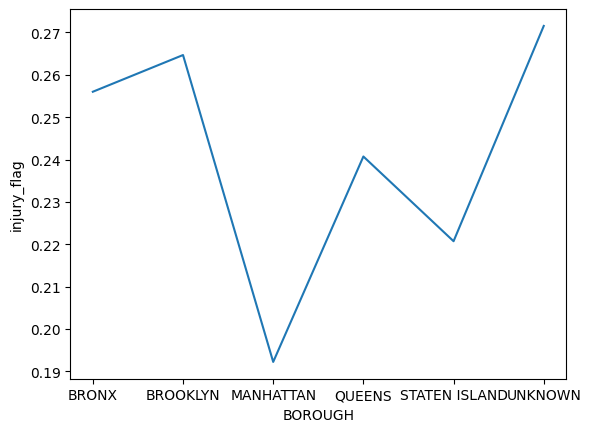

In [48]:
sns.lineplot(main_df.groupby('BOROUGH')['injury_flag'].mean())

In [49]:
main_df.groupby('BOROUGH')['NUMBER OF PERSONS INJURED'].mean()

BOROUGH
BRONX            0.349503
BROOKLYN         0.352813
MANHATTAN        0.229759
QUEENS           0.320308
STATEN ISLAND    0.301827
UNKNOWN          0.389915
Name: NUMBER OF PERSONS INJURED, dtype: float64

<Axes: xlabel='NUMBER OF PERSONS INJURED', ylabel='Count'>

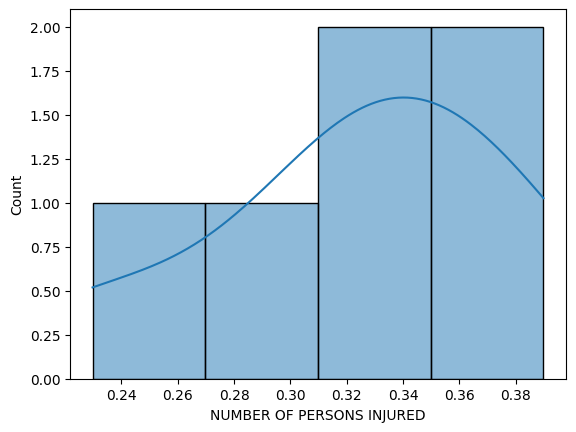

In [50]:
sns.histplot(main_df.groupby('BOROUGH')['NUMBER OF PERSONS INJURED'].mean(),kde=True)

<Axes: xlabel='NUMBER OF PERSONS INJURED', ylabel='NUMBER OF PEDESTRIANS KILLED'>

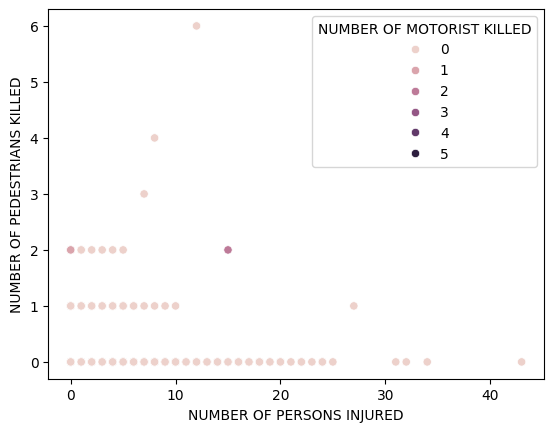

In [51]:
plt.Figure(figsize=(6,6))
sns.scatterplot(data=main_df,x='NUMBER OF PERSONS INJURED',y='NUMBER OF PEDESTRIANS KILLED',hue='NUMBER OF MOTORIST KILLED')

<Axes: xlabel='NUMBER OF PERSONS INJURED', ylabel='NUMBER OF PEDESTRIANS KILLED'>

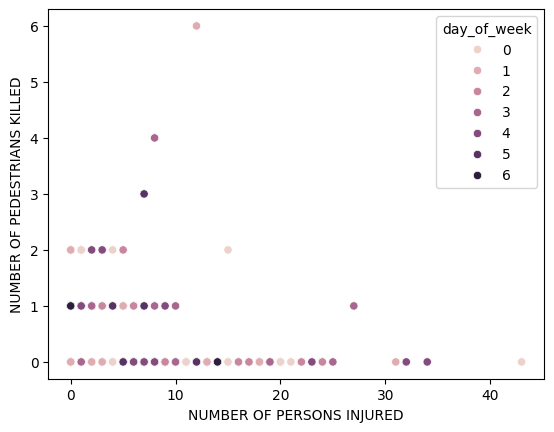

In [52]:
plt.Figure(figsize=(6,6))
sns.scatterplot(data=main_df,x='NUMBER OF PERSONS INJURED',y='NUMBER OF PEDESTRIANS KILLED',hue='day_of_week')

In [53]:
main_df=main_df.drop(columns=['NUMBER OF PERSONS INJURED','NUMBER OF PERSONS KILLED','NUMBER OF PEDESTRIANS INJURED','NUMBER OF PEDESTRIANS KILLED','NUMBER OF CYCLIST INJURED','NUMBER OF CYCLIST KILLED','NUMBER OF MOTORIST INJURED','NUMBER OF MOTORIST KILLED'])

In [72]:
main_df['BOROUGH']=main_df['BOROUGH'].map({"BRONX": 0,"BROOKLYN": 1,"MANHATTAN": 2,"QUEENS": 3,
    "STATEN ISLAND": 4,
    "UNKNOWN": 5
})

In [73]:
main_df['vehicle_category'] = main_df['vehicle_category'].map({"Car":0,"SUV":1,"Other":2,"Truck":3})

In [74]:
main_df = main_df.drop(columns=['CRASH DATE','COLLISION_ID'])

In [78]:
top10 = main_df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().nlargest(10).index
top10=top10.drop("Unspecified")
def factor(x):
    if x in top10:
        return 1
    elif x=="Unspecified":
        return 0
    else:
        return 0
    



In [79]:
main_df['CONTRIBUTING FACTOR VEHICLE 1'] = main_df['CONTRIBUTING FACTOR VEHICLE 1'].apply(factor)

In [80]:
from sklearn.model_selection import train_test_split

In [81]:
train_df,test_df = train_test_split(main_df)

In [82]:
train_df.head()

,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,CONTRIBUTING FACTOR VEHICLE 1,day_of_week,is_weekend,hour,injury_flag,vehicle_category
1960739,4,10314,40.614470,-74.122870,1,3,0,10,0,0
1194717,4,10301,40.644073,-74.077774,1,2,0,8,0,2
1092751,2,10017,40.753000,-73.969894,1,5,1,6,0,2
433924,3,11385,40.710420,-73.859640,1,6,1,17,0,1
562196,1,11233,40.678276,-73.910805,1,0,0,14,0,1


In [83]:
train_df.shape

(1527297, 10)

In [84]:
test_df.shape

(509100, 10)

In [85]:
train_df.describe()

,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,CONTRIBUTING FACTOR VEHICLE 1,day_of_week,is_weekend,hour,injury_flag,vehicle_category
count,1.527297e+06,1.527297e+06,1.527297e+06,1.527297e+06,1.527297e+06,1.527297e+06,1.527297e+06,1.527297e+06,1.527297e+06,1.527297e+06
mean,2.507671e+00,8.278146e+03,4.072397e+01,-7.392705e+01,4.901280e-01,2.925307e+00,2.563529e-01,1.316899e+01,2.467758e-01,6.839154e-01
std,1.703243e+00,4.634787e+03,7.991279e-02,9.670341e-01,4.999027e-01,1.950230e+00,4.366191e-01,5.801279e+00,4.311353e-01,8.757269e-01
min,0.000000e+00,0.000000e+00,3.078418e+01,-2.013600e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.000200e+04,4.066796e+01,-7.397492e+01,0.000000e+00,1.000000e+00,0.000000e+00,9.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,1.046300e+04,4.072071e+01,-7.392723e+01,0.000000e+00,3.000000e+00,0.000000e+00,1.400000e+01,0.000000e+00,0.000000e+00
75%,4.000000e+00,1.122800e+04,4.076987e+01,-7.386748e+01,1.000000e+00,5.000000e+00,1.000000e+00,1.800000e+01,0.000000e+00,1.000000e+00
max,5.000000e+00,1.234500e+04,4.334444e+01,-3.276851e+01,1.000000e+00,6.000000e+00,1.000000e+00,2.300000e+01,1.000000e+00,3.000000e+00


In [86]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1527297 entries, 1960739 to 178796
Data columns (total 10 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   BOROUGH                        1527297 non-null  int64  
 1   ZIP CODE                       1527297 non-null  int64  
 2   LATITUDE                       1527297 non-null  float64
 3   LONGITUDE                      1527297 non-null  float64
 4   CONTRIBUTING FACTOR VEHICLE 1  1527297 non-null  int64  
 5   day_of_week                    1527297 non-null  int64  
 6   is_weekend                     1527297 non-null  int64  
 7   hour                           1527297 non-null  int32  
 8   injury_flag                    1527297 non-null  int64  
 9   vehicle_category               1527297 non-null  int64  
dtypes: float64(2), int32(1), int64(7)
memory usage: 122.3 MB


In [87]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 509100 entries, 942373 to 1976683
Data columns (total 10 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   BOROUGH                        509100 non-null  int64  
 1   ZIP CODE                       509100 non-null  int64  
 2   LATITUDE                       509100 non-null  float64
 3   LONGITUDE                      509100 non-null  float64
 4   CONTRIBUTING FACTOR VEHICLE 1  509100 non-null  int64  
 5   day_of_week                    509100 non-null  int64  
 6   is_weekend                     509100 non-null  int64  
 7   hour                           509100 non-null  int32  
 8   injury_flag                    509100 non-null  int64  
 9   vehicle_category               509100 non-null  int64  
dtypes: float64(2), int32(1), int64(7)
memory usage: 40.8 MB


In [88]:
test_df.describe()

,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,CONTRIBUTING FACTOR VEHICLE 1,day_of_week,is_weekend,hour,injury_flag,vehicle_category
count,509100.000000,509100.000000,509100.000000,509100.000000,509100.000000,509100.000000,509100.000000,509100.000000,509100.000000,509100.000000
mean,2.505290,8275.405138,40.724074,-73.924798,0.490373,2.919961,0.255679,13.155834,0.246840,0.682059
std,1.704538,4636.114893,0.079372,0.810858,0.499908,1.949648,0.436242,5.801527,0.431173,0.874733
min,0.000000,0.000000,40.499479,-201.237060,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,10002.000000,40.667908,-73.974785,0.000000,1.000000,0.000000,9.000000,0.000000,0.000000
50%,2.000000,10463.000000,40.720854,-73.927070,0.000000,3.000000,0.000000,14.000000,0.000000,0.000000
75%,4.000000,11228.000000,40.769900,-73.867361,1.000000,5.000000,1.000000,18.000000,0.000000,1.000000
max,5.000000,11697.000000,42.318317,-32.768513,1.000000,6.000000,1.000000,23.000000,1.000000,3.000000


In [89]:
x_train = train_df.drop(columns=['injury_flag'])
y_train = train_df['injury_flag']

x_test = test_df.drop(columns=['injury_flag'])
y_test = test_df['injury_flag']

In [90]:
from sklearn.linear_model import LogisticRegression

In [91]:
logreg_model = LogisticRegression()
logreg_model.fit(x_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [92]:
train_pred = logreg_model.predict(x_train)

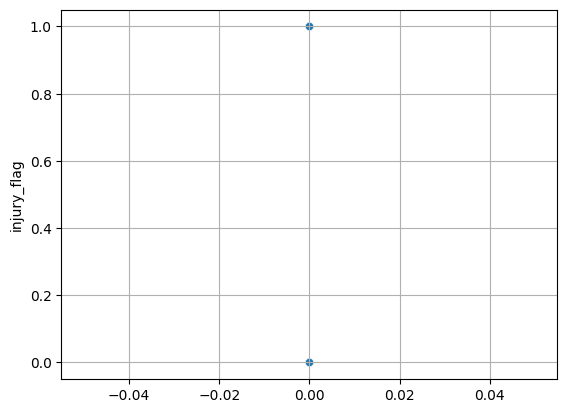

In [93]:
sns.scatterplot(x=train_pred,y=y_train)
plt.grid()

In [95]:
train_residual= train_pred - y_train

In [97]:
train_residual.sum()

np.int64(-376900)

In [99]:
test_pred = logreg_model.predict(x_test)

In [101]:
coef_df = pd.DataFrame({
    "feature": logreg_model.feature_names_in_,
    "coefficient": logreg_model.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values(by="abs_coefficient", ascending=False)

coef_df.head(20)

,feature,coefficient,abs_coefficient
0,BOROUGH,-0.043027,0.043027
8,vehicle_category,0.040461,0.040461
7,hour,0.011317,0.011317
3,LONGITUDE,0.009780,0.009780
6,is_weekend,0.007369,0.007369
5,day_of_week,0.007111,0.007111
2,LATITUDE,-0.006698,0.006698
4,CONTRIBUTING FACTOR VEHICLE 1,0.004938,0.004938
1,ZIP CODE,-0.000026,0.000026
